In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sampledataset/sampled_data.csv


In [3]:
import requests
import pandas as pd
import time
import numpy as np

API_KEY = "service.fbf6af88851c4a1f8f7066f55a1feb4d"
def get_neighborhood_from_neshan(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return None

    url = f"https://api.neshan.org/v5/reverse?lat={lat}&lng={lon}"
    headers = {"Api-Key": API_KEY}

    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            print('response ok')
            data = response.json()
            print(data)
            return (
                data.get("neighbourhood") or data.get("route_name"))
        else:
            print('not response')
            return None
    except:
        return None

lat = 35.778664
lon = 51.757549
print(get_neighborhood_from_neshan(lat,lon))

None


In [4]:
import os

os.listdir("/kaggle/input/sampledataset")

['sampled_data.csv']

In [5]:
import pandas as pd

file_path = "/kaggle/input/sampledataset/sampled_data.csv"

df = pd.read_csv(file_path)
print(df.head())

/tmp/ipykernel_109/2165036335.py:5: DtypeWarning: Columns (10,26,28,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


          cat2_slug       cat3_slug          city_slug neighborhood_slug  \
0   commercial-rent       shop-rent             tehran      kooy-e-bimeh   
1  residential-sell  apartment-sell              urmia               NaN   
2   commercial-rent     office-rent             tehran          niavaran   
3  residential-sell  apartment-sell  andisheh-new-town               NaN   
4    temporary-rent           villa           behbahan               NaN   

      created_at_month    user_type  \
0  2024-05-01 00:00:00  مشاور املاک   
1  2024-11-01 00:00:00          NaN   
2  2024-07-01 00:00:00  مشاور املاک   
3  2024-12-01 00:00:00          NaN   
4  2024-12-01 00:00:00          NaN   

                                         description  \
0  ✔مناسب  مشاغل پروتئنی و دفتر بیمه  و لبنیات \n...   
1  با سلام خدمت هشهریان عزیز\n\nواحد دومین قطعه ا...   
2  ۱۳۵ متر واحد لوکس به همراه تراس قابل چیدمان \n...   
3  ⚜️⚜️⚜️املاک بزرگ باور⚜️⚜️⚜️\n\n56 متر غرق در ن...   
4  سلام درود همشهریان و مهما

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


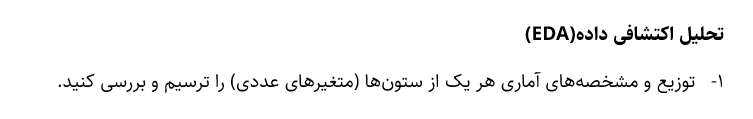
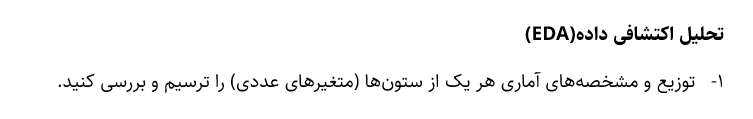

In [7]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [8]:
df.describe(include='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,150000,150000,150000,65655,150000,43177,150000,149991,52824,5.258800e+04,...,4116,4396.000000,3511,1.508000e+03,2.626000e+03,1.532000e+03,1.972000e+03,98457.000000,98457.000000,50949.000000
unique,6,16,416,1105,32,2,149496,141713,3,NaN,...,5,NaN,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,residential-sell,apartment-sell,tehran,elahiyehblvd,2024-08-01 00:00:00,مشاور املاک,❌فروش ویلا و زمین زیرقیمت منطقه و بدون واسطه ب...,خانه ویلایی,مقطوع,NaN,...,jungle,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,83958,45804,28844,1030,19949,38207,31,283,43600,NaN,...,2546,NaN,954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.082054e+10,...,NaN,6.504322,NaN,8.781894e+08,1.921802e+11,4.661297e+09,5.763495e+08,34.995110,51.610204,465.420322
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.672913e+12,...,NaN,7.658688,NaN,2.907156e+10,9.768887e+12,1.511129e+11,1.452190e+10,2.367389,3.163071,125.515153
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,...,NaN,1.000000,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.710484,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.111110e+05,...,NaN,3.000000,NaN,5.000000e+04,4.000000e+05,6.000000e+05,5.004500e+05,34.569145,50.655338,500.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+06,...,NaN,4.000000,NaN,1.000000e+05,8.000000e+05,1.200000e+06,1.200000e+06,35.723194,51.342411,500.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+07,...,NaN,7.000000,NaN,2.000000e+05,1.700000e+06,2.500000e+06,2.500000e+06,36.308140,51.783882,500.000000


In [9]:
df['rooms_count'].unique()
df['rooms_count'] = df['rooms_count'].replace({
    'یک' : '1',
    'دو' : '2',
    'سه' : '3',
    'چهار': '4',
    'بدون اتاق' : '0',
    'پنج یا بیشتر' : '5'    
})
df['rooms_count'].unique()
df['rooms_count'] = pd.to_numeric(df['rooms_count'] , errors = 'coerce')
df['rooms_count']

0         0.0
1         2.0
2         0.0
3         1.0
4         2.0
         ... 
149995    2.0
149996    2.0
149997    1.0
149998    1.0
149999    2.0
Name: rooms_count, Length: 150000, dtype: float64

In [8]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude= ['number']).columns

print("Numerics: ", num_cols.tolist())
print('Categories: ', cat_cols.tolist())

Numerics:  ['rent_value', 'price_value', 'credit_value', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'rooms_count', 'regular_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends', 'location_latitude', 'location_longitude', 'location_radius']
Categories:  ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_to_single', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_business_deed', 'floor', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building

In [9]:
df[num_cols].describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,rooms_count,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,5.258800e+04,8.542300e+04,5.269800e+04,5.269700e+04,1.081400e+04,5.257600e+04,1.081400e+04,2.799000e+04,1.470290e+05,127027.000000,4396.000000,1.508000e+03,2.626000e+03,1.532000e+03,1.972000e+03,98457.000000,98457.000000,50949.000000
mean,4.082054e+10,2.127063e+10,6.343155e+10,6.343275e+10,8.800685e+08,4.082986e+10,1.623233e+07,3.331458e+03,3.930399e+03,1.853881,6.504322,8.781894e+08,1.921802e+11,4.661297e+09,5.763495e+08,34.995110,51.610204,465.420322
std,4.672913e+12,7.446300e+11,5.264874e+12,5.264924e+12,2.217832e+09,4.673446e+12,4.695248e+07,7.294707e+04,1.197414e+05,0.989438,7.658688,2.907156e+10,9.768887e+12,1.511129e+11,1.452190e+10,2.367389,3.163071,125.515153
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.710484,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.025000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,1.000000,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.004500e+05,34.569145,50.655338,500.000000
50%,5.000000e+06,2.805000e+09,2.500000e+08,2.500000e+08,4.200000e+08,5.000000e+06,6.000000e+06,2.000000e+02,1.020000e+02,2.000000,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.200000e+06,35.723194,51.342411,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,9.000000e+08,1.200000e+07,1.500000e+07,2.900000e+02,1.650000e+02,2.000000,7.000000,2.000000e+05,1.700000e+06,2.500000e+06,2.500000e+06,36.308140,51.783882,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,1.250000e+11,1.000000e+15,1.500000e+09,6.666666e+06,1.000000e+07,5.000000,50.000000,1.111111e+12,5.006007e+14,5.806808e+12,4.805807e+11,39.661606,62.706940,500.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


KeyboardInterrupt: 

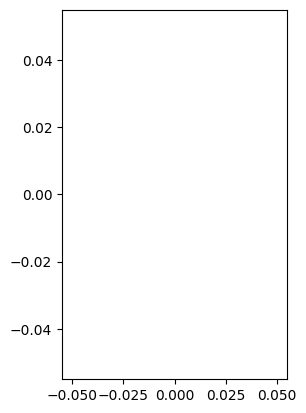

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


some_num_cols = ['rent_value', 'price_value', 'land_size', 'building_size']

for col in some_num_cols:
    plt.subplot(1,2,1)
    
    sns.histplot(df[col]/1e12)
    #plt.xticks(np.arange(0, 1.1e15, 0.2e15) , [f'{int(x/1e12)}T' for x in np.arange(0, 1.1e15, 0.2e15)])
    plt.xlabel(f'{col} in Trillions')
    plt.title(f'Histogram of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col]/1e12)
    #plt.xticks(np.arange(0, 1.1e15, 0.2e15) , [f'{int(x/1e12)}T' for x in np.arange(0, 1.1e15, 0.2e15)])
    plt.xlabel(f'{col} in Trillions')
    plt.title(f'Boxplot of {col}')

    plt.show()



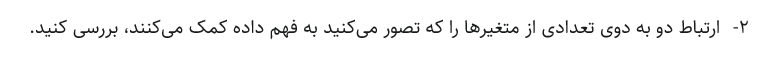

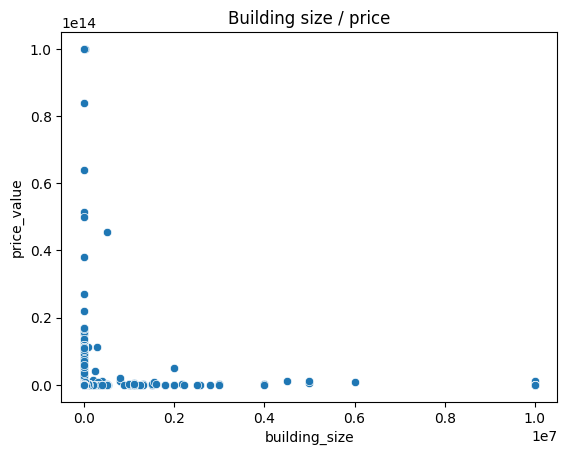

,building_size,price_value
building_size,1.000000,0.011608
price_value,0.011608,1.000000


In [12]:
#price_value vs building_size 

import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = 'building_size', y = 'price_value', data = df)
plt.title('Building size / price')
plt.show()

df[['building_size', 'price_value']].corr()

df[].corr()
#headmap


In [ ]:
df['construction_year']

In [ ]:
#price_value vs construction_year

sns.scatterplot(x = 'construction_year', y = 'price_value', data = df)
plt.title('Construction_year / price')
plt.show()

In [13]:
df['construction_year'].unique()

array(['۱۳۹۰', '۱۴۰۳', '۱۴۰۲', '۱۳۹۹', nan, '۱۳۹۷', '۱۳۹۵', '۱۳۸۵',
       '۱۳۷۲', '۱۳۸۶', '۱۳۸۹', '۱۴۰۱', '۱۳۹۳', '۱۳۹۴', '۱۳۸۸', '۱۳۹۸',
       '۱۳۹۶', '۱۳۷۶', '۱۳۷۱', '۱۳۸۷', '۱۳۷۴', '۱۳۹۲', '۱۴۰۰',
       'قبل از ۱۳۷۰', '۱۳۸۱', '۱۳۹۱', '۱۳۸۰', '۱۳۷۹', '۱۳۸۲', '۱۳۸۳',
       '۱۳۷۳', '۱۳۷۸', '۱۳۷۵', '۱۳۸۴', '۱۳۷۷'], dtype=object)

In [ ]:
df['new_construction_year'] = pd.to_numeric(df['construction_year'], errors = 'coerce')
df['new_construction_year']

In [14]:
persian_to_english = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

df['new_construction_year'] = (
    df['construction_year']
    .astype(str)
    .replace('قبل از ۱۳۷۰', '1369')  # or any representative value
    .apply(lambda x: x.translate(persian_to_english))
)

df['new_construction_year'] = pd.to_numeric(df['new_construction_year'], errors = 'coerce')

df['new_construction_year'] = df['new_construction_year'].astype('Int64')

df['new_construction_year']



0         1390
1         1403
2         1402
3         1399
4         <NA>
          ... 
149995    1401
149996    1393
149997    1375
149998    <NA>
149999    1383
Name: new_construction_year, Length: 150000, dtype: Int64

In [15]:
avg_price_per_year = df.groupby('new_construction_year')['price_value'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('new_construction_year')
avg_price_per_year['price_value'] = avg_price_per_year['price_value']/1e6

avg_price_per_year

#رنگ بر اساس فیمت فروش و اجاره و شکل بر اساس تجاری و مسکونی


,new_construction_year,price_value
0,1369,12380.044537
1,1371,10919.291417
2,1372,86515.411162
3,1373,9977.869053
4,1374,10571.026971
5,1375,11483.649314
6,1376,8107.937449
7,1377,11420.876029
8,1378,9642.819912
9,1379,11544.147990


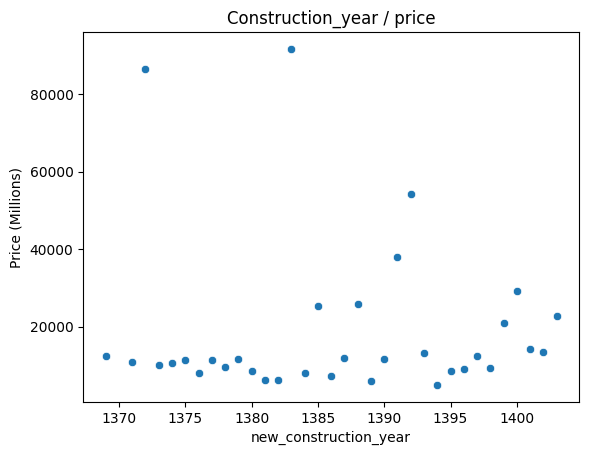

In [16]:
#price_value vs construction_year

sns.scatterplot(x = 'new_construction_year', y = 'price_value', data = avg_price_per_year)
plt.ylabel('Price (Millions)')
plt.title('Construction_year / price')
plt.show()

In [20]:
df['rooms_count'] = df['rooms_count'].astype('Int64')

avg_price_per_room = df.groupby('rooms_count')['price_value'].mean().reset_index()
avg_price_per_room = avg_price_per_room.sort_values('rooms_count')
avg_price_per_room['price_value'] = avg_price_per_room['price_value']/1e6


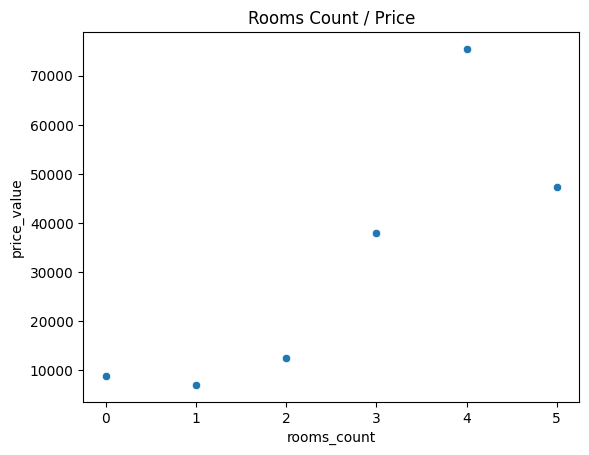

In [21]:
#price_value vs rooms_count

sns.scatterplot(x='rooms_count', y='price_value', data=avg_price_per_room)
plt.title('Rooms Count / Price')
plt.show()

In [22]:
#price_value vs property_type

df['property_type'].unique()

array([nan, 'jungle', 'other', 'jungle-mountain', 'beach', 'mountain'],
      dtype=object)

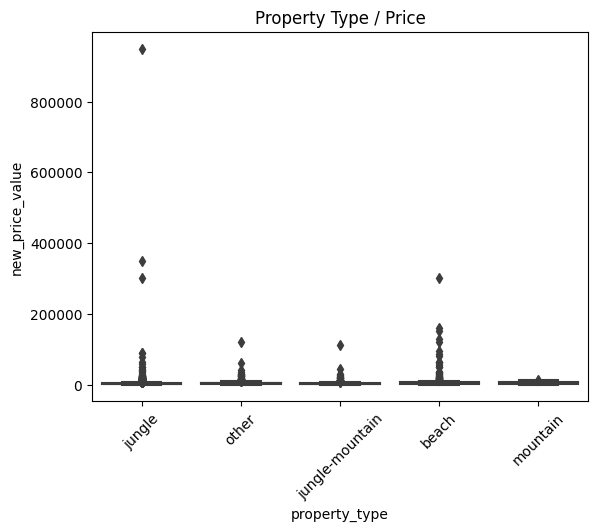

In [23]:
df['new_price_value'] = df['price_value']/1e6
sns.boxplot(x='property_type', y='new_price_value', data=df)
plt.xticks(rotation=45)
plt.title('Property Type / Price')
plt.show()

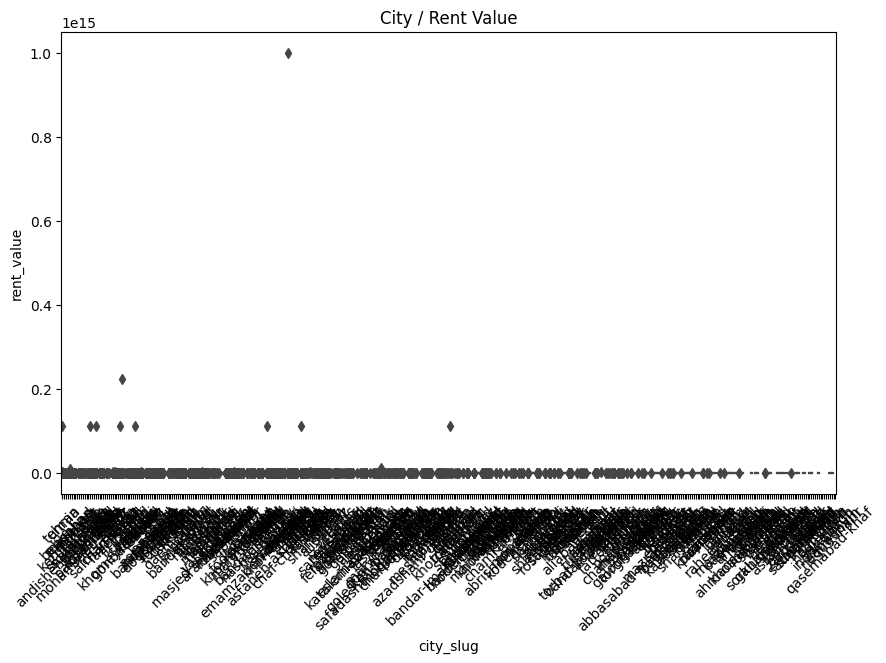

In [26]:
#City_slug vs rent_value

plt.figure(figsize=(10,6))
sns.boxplot(x='city_slug', y='rent_value', data=df)
plt.xticks(rotation=45)
plt.title('City / Rent Value')
plt.show()

In [24]:

df['city_slug'].describe()


count     150000
unique       416
top       tehran
freq       28844
Name: city_slug, dtype: object

In [25]:
df['city_slug'].value_counts()

city_slug
tehran         28844
mashhad        10272
karaj           7398
isfahan         5515
shiraz          5450
               ...  
anbaralum          1
yanghagh           1
inche-borun        1
tabaghdeh          1
jelin              1
Name: count, Length: 416, dtype: int64

In [ ]:
df['city_slug'].value_counts().get('zahedan', 0)


In [27]:
dff = df.groupby('city_slug')['rent_value'].mean().reset_index()
print(dff.loc[dff['city_slug']=='tehran'])
print(dff.loc[dff['city_slug']=='zahedan'])

    city_slug    rent_value
391    tehran  9.024038e+09
    city_slug    rent_value
408   zahedan  2.512569e+12


In [28]:
avg_rent_per_city = df.groupby('city_slug')['rent_value'].mean().reset_index()
avg_rent_per_city['rent_value'] = avg_rent_per_city['rent_value']/1e6
avg_rent_per_city = avg_rent_per_city.sort_values('rent_value', ascending=False)
avg_rent_per_city

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,city_slug,rent_value
408,zahedan,2.512569e+06
201,khorramshahr,2.315048e+06
217,kuhdasht,2.267807e+06
196,khomeyni-shahr,2.267581e+06
103,dezful,4.632951e+05
...,...,...
371,simin-shahr,NaN
380,tabaghdeh,NaN
386,takht,NaN
403,yanghagh,NaN


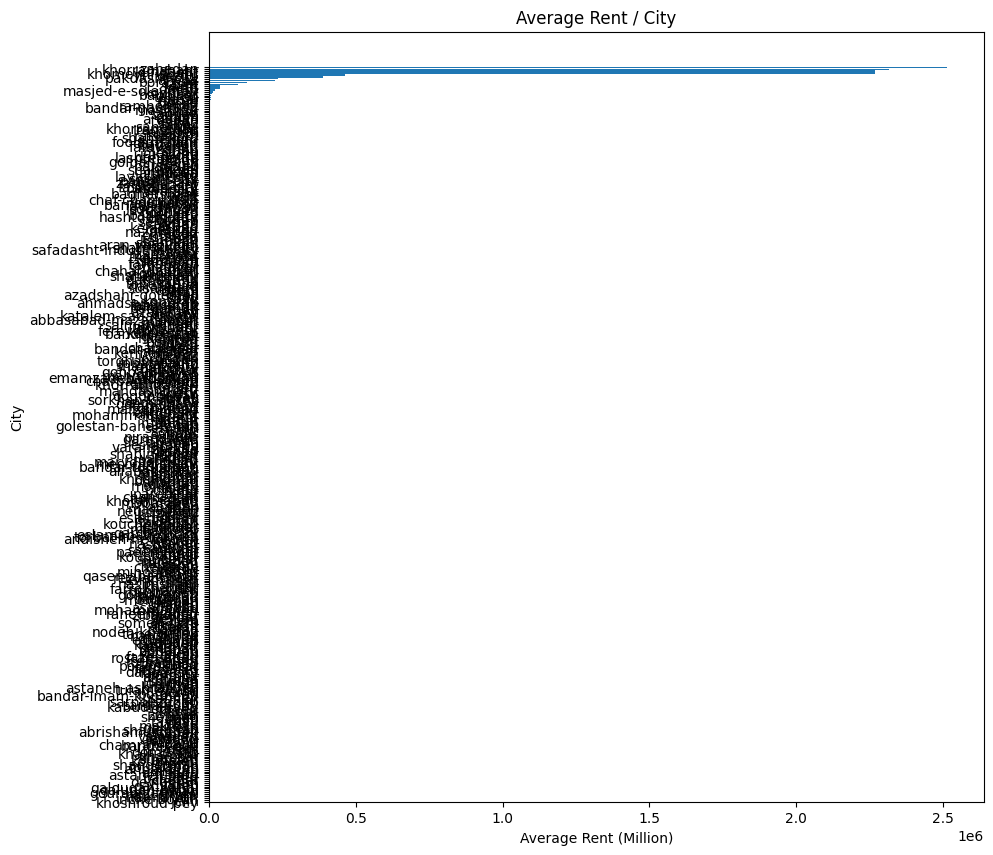

In [29]:
plt.figure(figsize = (10, 10))

plt.barh(
    avg_rent_per_city['city_slug'],  
    avg_rent_per_city['rent_value']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis() 
plt.show()


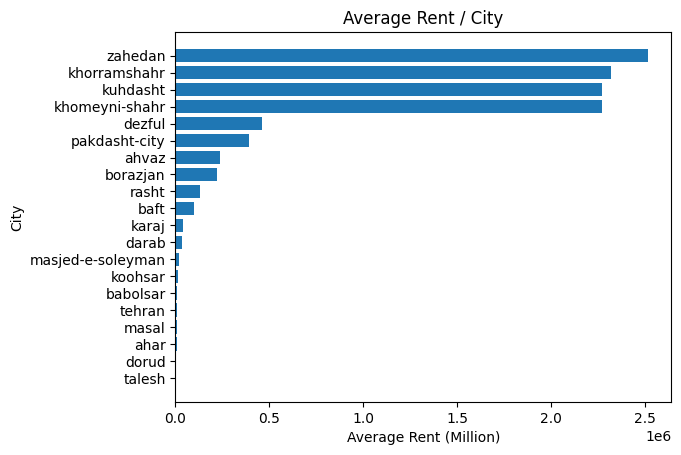

In [31]:
avg_rent_per_city_10 = avg_rent_per_city.head(20)
#plt.figure(figsize = (10, 10))
plt.barh(
    avg_rent_per_city_10['city_slug'],  
    avg_rent_per_city_10['rent_value']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis() 
plt.show()

In [ ]:
#rent_value vs rooms_count

df['new_rent_value'] = df['rent_value']/1e6
sns.boxplot(x='rooms_count', y='new_rent_value', data=df)
plt.title('Rooms Count vs Rent Value')
plt.show()

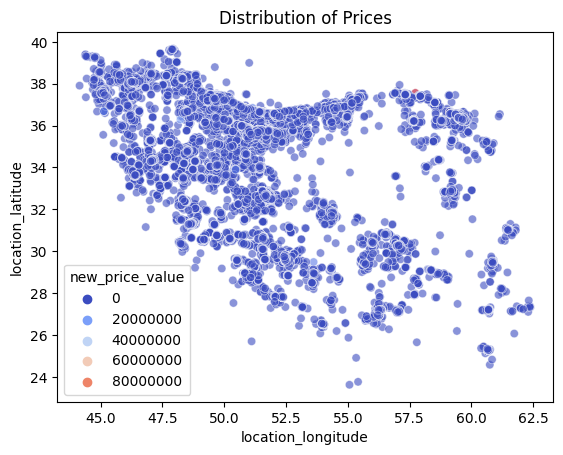

In [32]:
#price_value vs location_latitude / location_longitude

sns.scatterplot(x='location_longitude', y='location_latitude', hue='new_price_value',
                data=df, palette='coolwarm', alpha=0.6)
plt.title('Distribution of Prices')
plt.show()


In [ ]:
df['price_log'] = np.log1p(df['price_value'])

sns.scatterplot(x='location_longitude', y='location_latitude', hue='price_log',
                data=df, palette='coolwarm', alpha=0.6)
plt.title('Distribution of Prices')
plt.show()


In [ ]:
df['price_log']

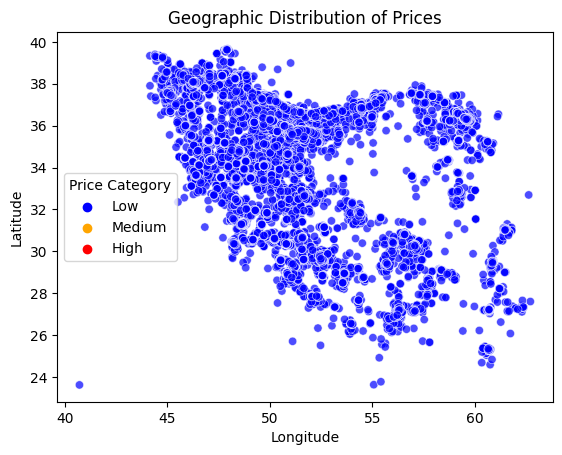

In [43]:
bins = [df['price_value'].min()-1, df['price_value'].quantile(0.33), 
        df['price_value'].quantile(0.66), df['price_value'].max()+1]
labels = ['Low', 'Medium', 'High']

df['price_category'] = pd.cut(df['price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude', 
    y='location_latitude', 
    hue='price_category', 
    data=df,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.7
)
plt.title('Geographic Distribution of Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()



In [ ]:
df['price_value'].nunique()
df['price_value'].describe()

In [34]:
df['price_value'].max() - df['price_value'].min()

99999999999999.0

In [42]:
df['price_per_meter'] = df['price_value'].notnull()/df['building_size']
df['price_per_meter'] = df['price_per_meter']*1000


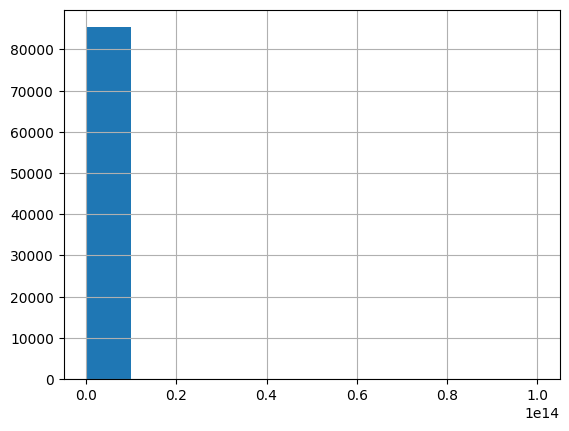

In [39]:
df['price_value'].hist()
plt.show()

In [37]:
n_unique = df['price_value'].nunique()
total = len(df['price_value'])
print(f"Unique values: {n_unique} / {total} ({n_unique/total*100:.1f}%)")


Unique values: 4860 / 150000 (3.2%)


داده‌ها هم تکراری و نزدیک هم هستند و هم چند نقطه پراکنده خیلی بزرگ وجود دارد.